In [1]:
import os
import mlflow
import shap

import pandas as pd

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train = pd.read_csv("../data/processed/raw_features/X_train.csv")
X_test = pd.read_csv("../data/processed/raw_features/X_test.csv")
y_train = pd.read_csv("../data/processed/target/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/target/y_test.csv").squeeze()

In [3]:
EXPERIMENT_NAME = "customer-churn-simple-no-complain-feature"

# =========================================================
# Paths
# =========================================================

ROOT_DIR = os.path.abspath("../")

DB_PATH = os.path.join(ROOT_DIR, "mlflow.db")

ARTIFACTS_DIR = os.path.join(ROOT_DIR, "mlartifacts")

# =========================================================
# MLflow
# =========================================================

mlflow.set_tracking_uri(
    f"sqlite:///{DB_PATH}"
)

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Get best run ordered by auc
best_run = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.auc DESC"],
    max_results=1
)

best_run = best_run.iloc[0]

print(
    "model_name:",
    best_run["tags.mlflow.runName"]
)
print("Best run id:", best_run.run_id)
print("Best auc:", best_run["metrics.pr_auc"])

model_name: random_forest
Best run id: 42d00bf3ec564f219d79ea567c2abde4
Best auc: 0.7333870674652824


In [4]:
# =========================================================
# Load best pipeline
# =========================================================

model_uri = f"runs:/{best_run['run_id']}/model"

best_pipeline = mlflow.sklearn.load_model(
    model_uri
)

In [5]:
# =========================================================
# Extract components
# =========================================================

preprocessor = best_pipeline.named_steps[
    'preprocessing'
]

model = best_pipeline.named_steps[
    'model'
]

In [6]:
# =========================================================
# Transform data
# =========================================================

X_train_transformed = preprocessor.transform(
    X_train
)

# Feature names after preprocessing
feature_names = (
    preprocessor.get_feature_names_out()
)

# Optional dataframe
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

In [7]:
# =========================================================
# Feature importance
# =========================================================

importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })
    .sort_values(
        'importance',
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df['cumulative_importance'] = (
    importance_df['importance']
    .cumsum()
)

print(
    importance_df.head(20)
)

                    feature  importance  cumulative_importance
0                  num__Age    0.200360               0.200360
1              num__Balance    0.106932               0.307292
2      num__EstimatedSalary    0.103885               0.411177
3         num__Point Earned    0.101981               0.513158
4          num__CreditScore    0.099098               0.612255
5      cat__NumOfProducts_2    0.073584               0.685840
6               num__Tenure    0.061714               0.747554
7      cat__NumOfProducts_3    0.045400               0.792954
8   num__Satisfaction Score    0.042486               0.835440
9      pass__IsActiveMember    0.035896               0.871337
10   cat__Geography_Germany    0.030211               0.901548
11         cat__Gender_Male    0.018882               0.920430
12          pass__HasCrCard    0.015792               0.936222
13      cat__Card Type_GOLD    0.013132               0.949355
14    cat__Card Type_SILVER    0.012946               0

The feature importance distribution indicates that churn prediction is primarily driven by:

- customer age
    - age
- financial behavior and engagement level
    - Balance
    - EstimatedSalary
    - Point earned
    - CreditScore
- and product adoption patterns.
    - NumOfProducts_2
    - NumOfProducts_3

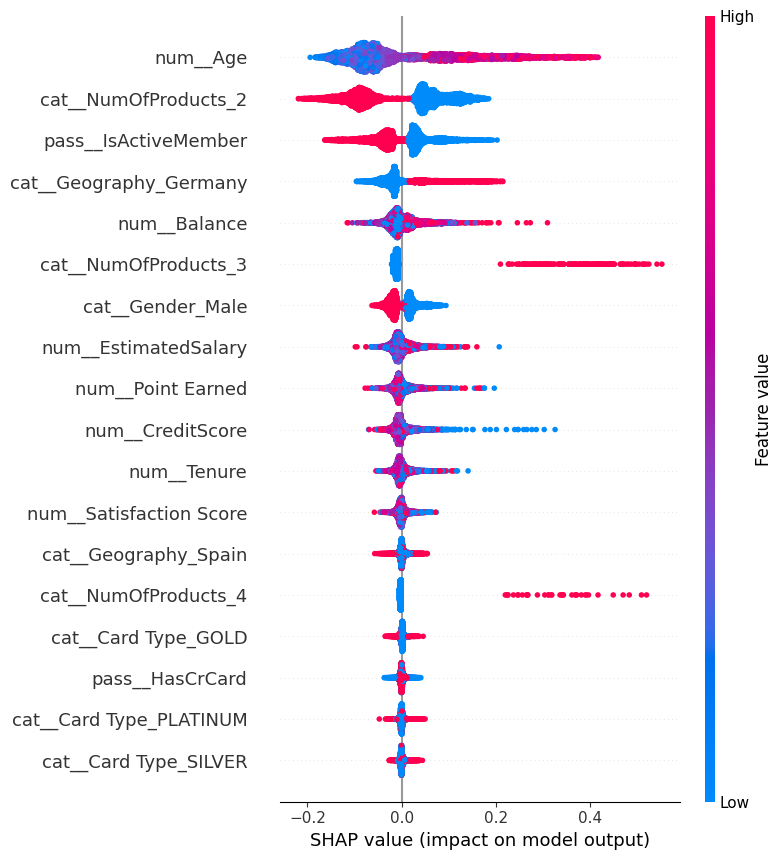

In [8]:
# =========================================================
# SHAP Analysis (Random Forest)
# =========================================================

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_train_transformed_df)

# For binary classification -> positive class
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed_df
)

Increases predicted churn probability:
- Higher age
- having 3 products
- having 4 products
- Being in Germany
- Being Female
- low credit scores

Decreases predicted churn probability:
- Lower age 
- having 2 products
- Being Male
- Being Active member

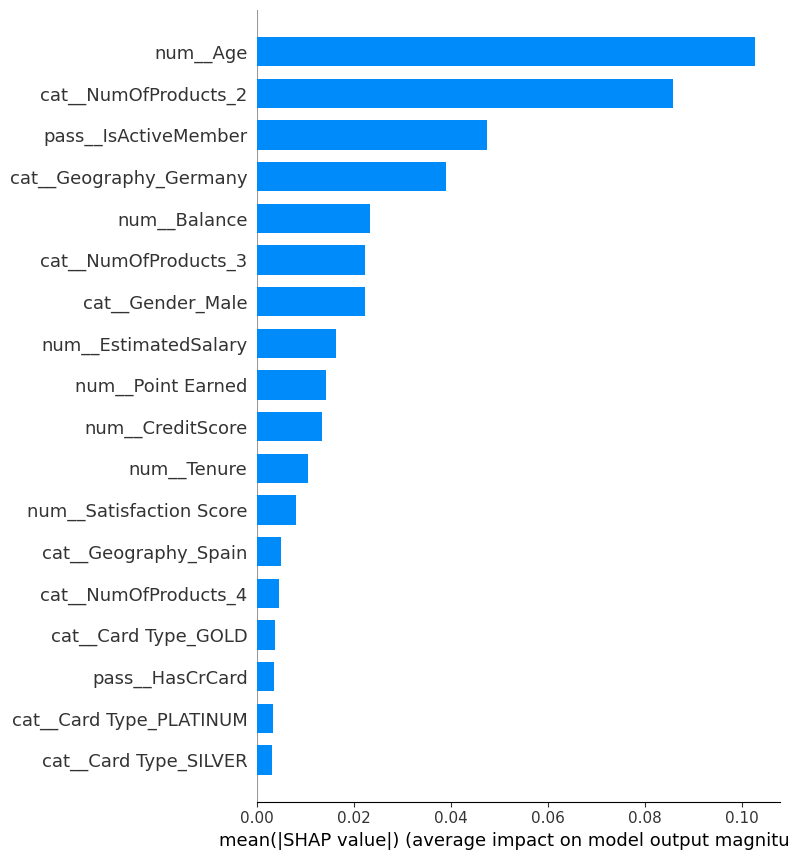

In [9]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed_df,
    plot_type="bar"
)

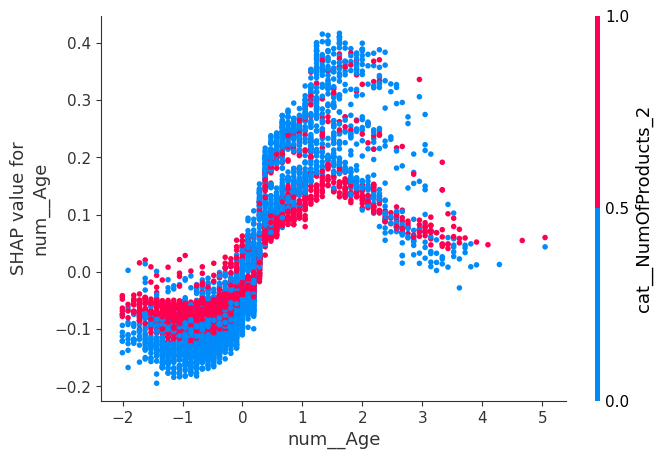

In [10]:
shap.dependence_plot(
    "num__Age",
    shap_values[:, :, 1],
    X_train_transformed_df
)

Age has a strongly nonlinear effect
younger people contribute to no churn 
middle age with number of products different than 2 contribute more to churn
old people contribute less to churn

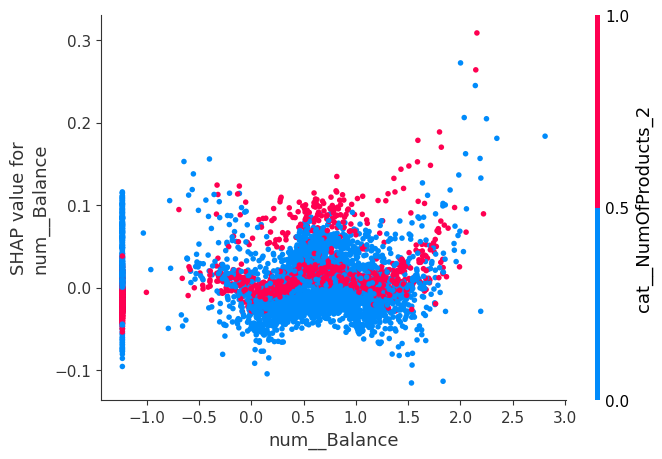

In [11]:
shap.dependence_plot(
    "num__Balance",
    shap_values[:, :, 1],
    X_train_transformed_df
)

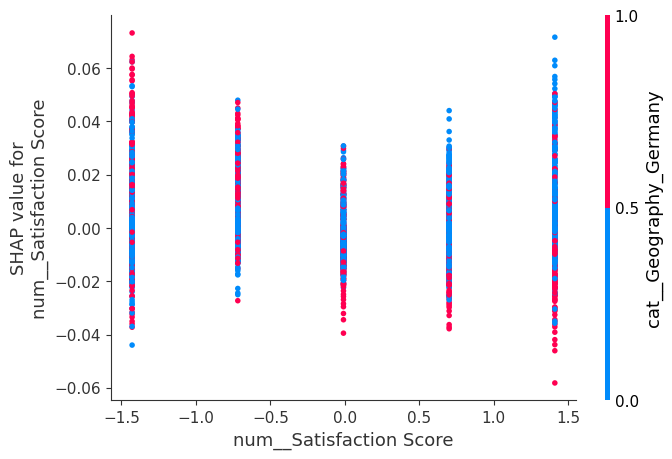

In [12]:
# nada
shap.dependence_plot(
    "num__Satisfaction Score",
    shap_values[:, :, 1],
    X_train_transformed_df
)

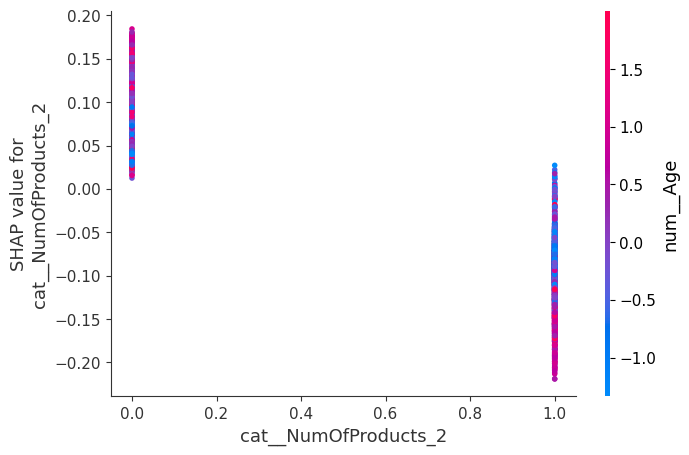

In [13]:
shap.dependence_plot(
    "cat__NumOfProducts_2",
    shap_values[:, :, 1],
    X_train_transformed_df
)

- older people with 2 products contribute to no churn
- older people with diffrent than 2 number of products contribute high to churn

In [14]:
X_train_transformed_df.columns

Index(['cat__Card Type_GOLD', 'cat__Card Type_PLATINUM',
       'cat__Card Type_SILVER', 'cat__NumOfProducts_2', 'cat__NumOfProducts_3',
       'cat__NumOfProducts_4', 'cat__Geography_Germany',
       'cat__Geography_Spain', 'cat__Gender_Male', 'num__Balance',
       'num__Point Earned', 'num__CreditScore', 'num__Age', 'num__Tenure',
       'num__Satisfaction Score', 'num__EstimatedSalary', 'pass__HasCrCard',
       'pass__IsActiveMember'],
      dtype='object')

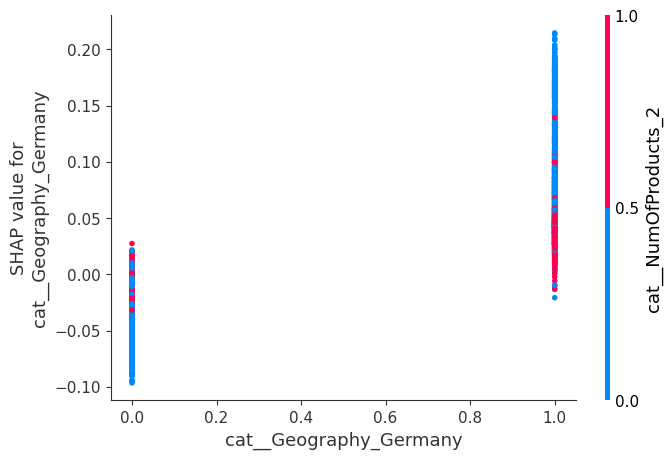

In [15]:
shap.dependence_plot(
    "cat__Geography_Germany",
    shap_values[:, :, 1],
    X_train_transformed_df
)

not germans with number of products different than 2 contribute to no churn
Germany people  with number of products equal to 2 contribute to churn

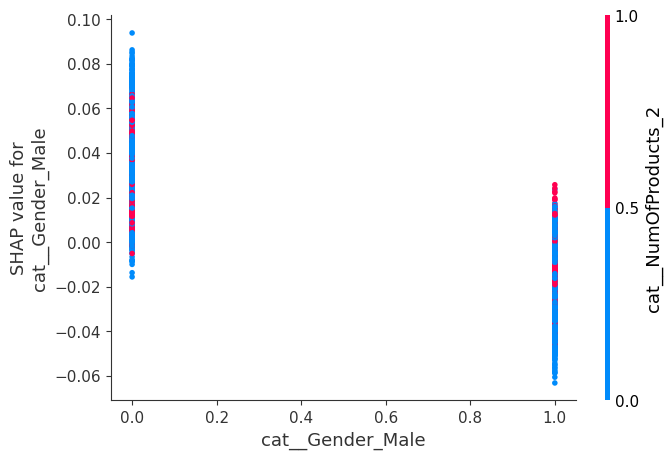

In [16]:
shap.dependence_plot(
    "cat__Gender_Male",
    shap_values[:, :, 1],
    X_train_transformed_df
)

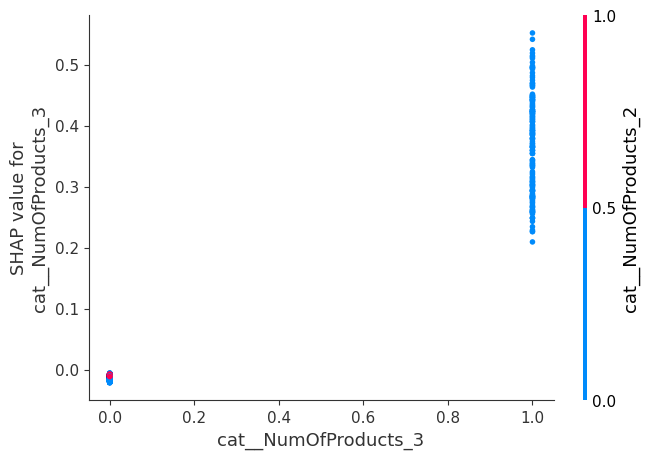

In [17]:
shap.dependence_plot(
    "cat__NumOfProducts_3",
    shap_values[:, :, 1],
    X_train_transformed_df
)